## Saving Single or Multiple graphs as png or to pdf

In [3]:
import pandas as pd
import numpy as np
from pydataset import data
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

In [13]:
df = pd.DataFrame({
    "Campus": ["New York", "Texas", "Seattle", "Washington", "New Jersey"],
    "Admissions": [1200, 850, 650, 520, 780],
    "Revenue": [145, 92, 71, 55, 88],
    "Applications": [6200, 4100, 3300, 2800, 3900]
})
df

,Campus,Admissions,Revenue,Applications
0,New York,1200,145,6200
1,Texas,850,92,4100
2,Seattle,650,71,3300
3,Washington,520,55,2800
4,New Jersey,780,88,3900


## Graphs

### Matplotlib pdf pages 
- Campus_Report.pdf
- Page 1 → Admission Bar
- Page 2 → Revenue Bar
- Page 3 → Applications vs Admissions

In [15]:
with PdfPages("Campus_Report.pdf") as pdf:
    # Title page
    fig = plt.figure(figsize=(8.27, 11.69))
    plt.axis("off")
    plt.text(0.5, 0.75, "Campus Performance Report", ha="center", fontsize=24)
    plt.text(0.5, 0.65, "Admissions, Applications and Revenue", ha="center", fontsize=16)
    plt.text(0.5, 0.55, "Prepared using Python\nJupyter Notebook",ha="center", fontsize=12)
    pdf.savefig(fig)
    plt.close(fig)
    
    # Page 1: Admissions bar chart
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(df["Campus"], df["Admissions"])
    ax.set_title("Campus-wise Admissions")
    ax.set_xlabel("Campus")
    ax.set_ylabel("Admissions")
    pdf.savefig(fig)
    plt.close(fig)
    # Page 2: Revenue bar chart
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(df["Campus"], df["Revenue"])
    ax.set_title("Campus-wise Revenue")
    ax.set_xlabel("Campus")
    ax.set_ylabel("Revenue in Cr")
    pdf.savefig(fig)
    plt.close(fig)
    # Page 3: Applications vs Admissions
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(df["Applications"], df["Admissions"])
    for i, row in df.iterrows():
        ax.text(row["Applications"], row["Admissions"], row["Campus"])
    ax.set_title("Applications vs Admissions")
    ax.set_xlabel("Applications")
    ax.set_ylabel("Admissions")
    pdf.savefig(fig)
    plt.close(fig)

## One Page per campus

In [18]:
data = pd.DataFrame({    "Campus": ['New York',  'New York', 'New York', 'Seattle', 'Seattle', 'Seattle', "Washington", "Washington", "Washington"],
    "Year": [2024, 2025, 2026,  2024, 2025, 2026,       2024, 2025, 2026],  "Admissions": [900, 1050, 1200,  700, 760, 850, 500, 590, 650]})
data

,Campus,Year,Admissions
0,New York,2024,900
1,New York,2025,1050
2,New York,2026,1200
3,Seattle,2024,700
4,Seattle,2025,760
5,Seattle,2026,850
6,Washington,2024,500
7,Washington,2025,590
8,Washington,2026,650


In [32]:
with PdfPages("Campus_Yearwise_Report.pdf") as pdf:
    for campus in data["Campus"].unique():
        temp = data[data["Campus"] == campus]
        fig, ax = plt.subplots(figsize=(9, 6))
        ax.plot(temp["Year"], temp["Admissions"], marker="o")
        ax.set_title(f"{campus} Admissions Trend")
        ax.set_xlabel("Year")
        ax.set_ylabel("Admissions")
        ax.set_xticks(data["Year"])
        ax.set_xticklabels(data["Year"])
        ax.grid(True)
        pdf.savefig(fig)
        plt.close(fig)

## Saving Plotly figures

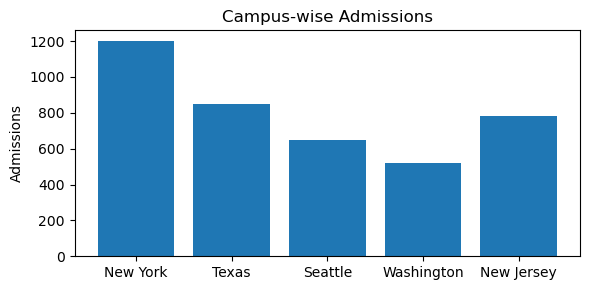

In [23]:
fig, ax = plt.subplots(figsize=(6,3))
ax.bar(df["Campus"], df["Admissions"])
ax.set_title("Campus-wise Admissions")
ax.set_ylabel("Admissions")
plt.tight_layout()
fig.savefig( "Admissions.png",  dpi=300,  bbox_inches="tight")
plt.show()

In [25]:
# Scatter
fig, ax = plt.subplots(figsize=(6,5))
ax.scatter(df["Applications"], df["Admissions"])
for _, row in df.iterrows():
    ax.text(row["Applications"], row["Admissions"], row["Campus"])
ax.set_title("Applications vs Admissions")
fig.savefig("Scatter.png", dpi=300, bbox_inches="tight")
plt.close(fig)  #no show here

## Multiple Figures
- saving in a loop

In [33]:
for campus in data["Campus"].unique():
    temp = data[data["Campus"]==campus]
    fig, ax = plt.subplots(figsize=(8,5))
    ax.plot(temp["Year"], temp["Admissions"],  marker="o", linewidth=2)
    ax.set_title(campus)
    plt.tight_layout()
    ax.set_xticks(data["Year"])
    ax.set_xticklabels(data["Year"])
    fig.savefig(f"{campus}.png",    dpi=300,bbox_inches="tight")
    plt.close(fig)

## Number the files

In [28]:
plots

['Admissions', 'Revenue', 'Applications']

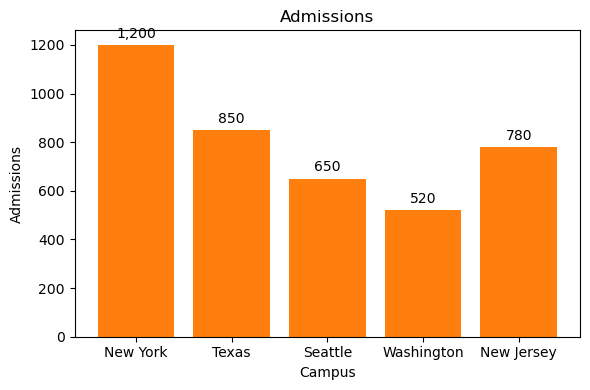

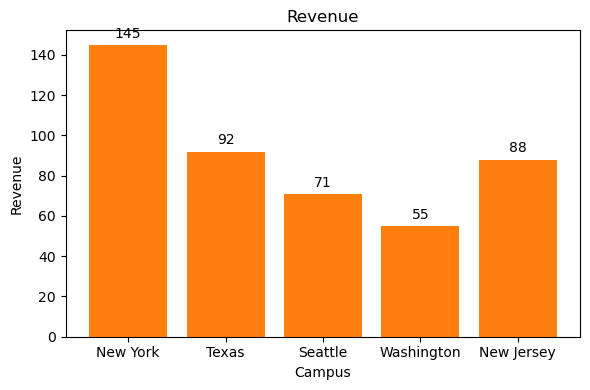

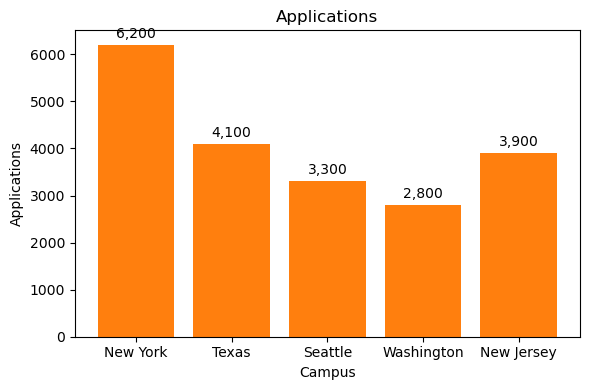

In [37]:
plots = ["Admissions", "Revenue", "Applications"]
for i, name in enumerate(plots, start=1):
    fig, ax = plt.subplots(figsize=(6,4))
    ax.bar(df["Campus"], df[name])
    bars = ax.bar(df['Campus'], df[name])
    ax.bar_label(bars, labels=[f"{x:,.0f}" for x in df[name]],  padding=3)
    ax.set_title(name)
    ax.set_xlabel("Campus")
    ax.set_ylabel(name)
    plt.tight_layout()
    fig.savefig(f"{i:02d}_{name}.png", dpi=300)
    plt.show()          # Display in notebook
    plt.close(fig)      # Close after saving

## Save into a folder


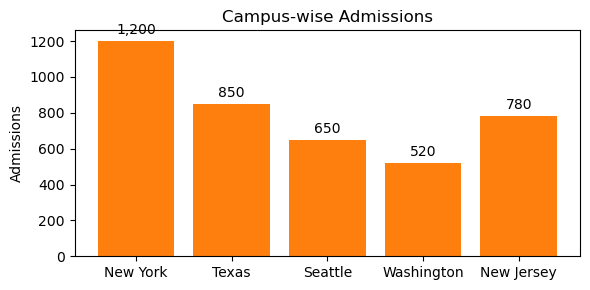

In [38]:
from pathlib import Path
Path("Figures").mkdir(exist_ok=True)
fig, ax = plt.subplots(figsize=(6,3))
bars = ax.bar(df['Campus'], df['Admissions'])
ax.bar_label(bars, labels=[f"{x:,.0f}" for x in df['Admissions']],  padding=3)
ax.bar(df["Campus"], df["Admissions"])
ax.set_title("Campus-wise Admissions")
ax.set_ylabel("Admissions")
plt.tight_layout()
fig.savefig("Figures/Admissions.png",    dpi=300,  bbox_inches="tight")

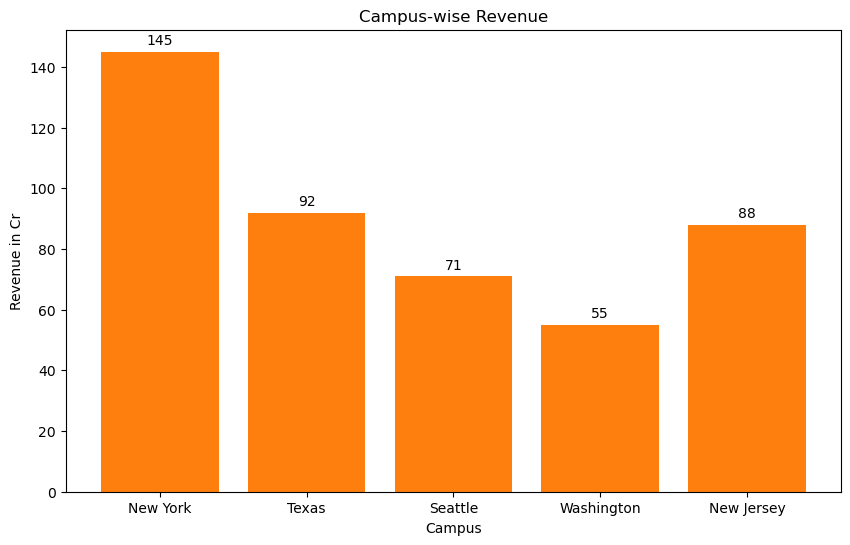

In [39]:
## save Figure
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(df["Campus"], df["Revenue"])
bars = ax.bar(df['Campus'], df['Revenue'])
ax.bar_label(bars, labels=[f"{x:,.0f}" for x in df['Revenue']],  padding=3)
ax.set_title("Campus-wise Revenue")
ax.set_xlabel("Campus")
ax.set_ylabel("Revenue in Cr")
fig.savefig(  "savefigplot.png",   dpi=300,              # Publication-quality resolution
    bbox_inches="tight",  # Trim extra whitespace
    facecolor="white",    # White background
    transparent=False)